In [1]:
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np
import os
import scipy
import pickle
import random

from neurolib.models.aln import ALNModel
from neurolib.models.rate_control import RateModel
import neurolib.utils.functions as func
from neurolib.utils import costFunctions as cost
from neurolib.utils import plotFunctions as plotFunc

plt.rcParams['image.cmap'] = 'plasma'
cpalette = sns.color_palette('plasma')
np.set_printoptions(precision=6)

font = {
    'family' : 'sans',
    'weight' : 'normal',
    'size'   : 14
       }

matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=16) 
matplotlib.rc('ytick', labelsize=16) 
matplotlib.rc('grid', c='0.5', ls='-', lw=0.5)  # solid gray grid lines
matplotlib.rc('savefig', dpi=300)       # higher res outputs
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

path = os.getcwd()

In [2]:
def step_control(maxI_ = 1.):
    control_ = aln.getZeroControl()
    for i_time in range(control_.shape[2]):
        if ( float(i_time/control_.shape[2]) < 0.1):
            control_[:,:2,i_time] = - maxI_
        elif ( float(i_time/control_.shape[2]) > 0.5 and float(i_time/control_.shape[2]) < 0.6 ):
            control_[:,:2,i_time] = maxI_
    return control_

In [105]:
def setinitvars(vars):
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                if aln.params[init_vars[iv]].ndim == 2:
                    aln.params[init_vars[iv]][0,:] = vars[sv]
                else:
                    aln.params[init_vars[iv]][:] = vars[sv]
    #setParametersALN(aln)
                    
def setParametersALN(model):
    model.params.rates_exc_init = np.array( [[0. * 0.01 * 0.5 ]] )
    model.params.rates_inh_init = np.array( [[0. * 0.01 * 0.5 ]] )
    model.params.mufe_init = np.array( [[0. * 3. * 0.5 ]] )  # mV/ms
    model.params.mufi_init = np.array( [[0. * 3. * 0.5 ]] )  # mV/ms
    model.params.IA_init = np.array( [[0. * 200. * 0.5 ]] )  # pA
    model.params.seem_init = np.array( [[0. * 0.5 * 0.5 ]] )
    model.params.seim_init = np.array( [[0. * 0.5 * 0.5 ]] )   
    model.params.seev_init = np.array( [[0. * 0.01 * 0.5 ]] )
    model.params.seiv_init = np.array( [[0. * 0.01 * 0.5 ]] )
    model.params.siim_init = np.array( [[0. * 0.5 * 0.5 ]] )
    model.params.siem_init = np.array( [[0. * 0.5 * 0.5 ]] )
    model.params.siiv_init = np.array( [[0. * 0.01 * 0.5 ]] )
    model.params.siev_init = np.array( [[0. * 0.01 * 0.5 ]] )
    model.params.mue_ou = np.array( [[0. * 0.4]] ) #* np.ones((model.params.N,))
    model.params.mui_ou = np.array( [[0. * 0.3]] ) #* np.ones((model.params.N,))

In [4]:
tol = 1e-24

c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

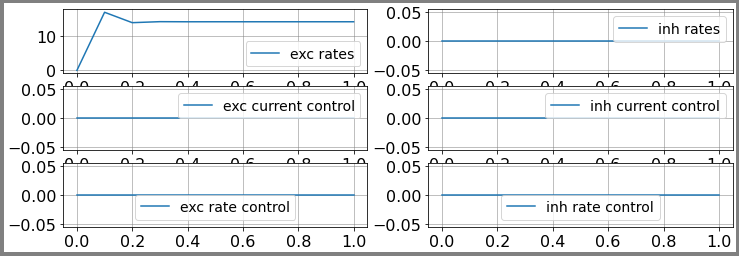

In [172]:
aln = RateModel()

aln.params['duration'] = 1.
aln.params.dt = 0.1
control0 = aln.getZeroControl()

# NO ADAPTATION
aln.params.IA_init = np.array([0.])
aln.params.a = 0.
aln.params.b = 0.

# no noise
aln.params.sigma_ou = 0.
aln.params.mue_ext_mean = 0.
aln.params.mui_ext_mean = 0.
aln.params.sigmae_ext = 0.
aln.params.sigmai_ext = 0.
aln.params.ext_exc_current = 0.
aln.params.ext_inh_current = 0.

# no delay
aln.params.signalV = 0.
aln.params.de = 0.
aln.params.di = 0.

aln.params.cie = 1.
aln.params.Jie_max = 1.
aln.params.tau_se = 1.
aln.params.tau_si = 1.
aln.params.C = 1.
aln.params.gL = 1.
aln.params.Ke = 1000.
aln.params.Ki = 1000.

setParametersALN(aln)

plotFunc.plot_traces(aln, control0)

output = aln.output_vars

state_vars = aln.state_vars
init_vars = aln.init_vars

high_state_vars = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        high_state_vars[i] = aln.state[state_vars[i]][0]
    else:
        high_state_vars[i] = aln.state[state_vars[i]][0,-2]

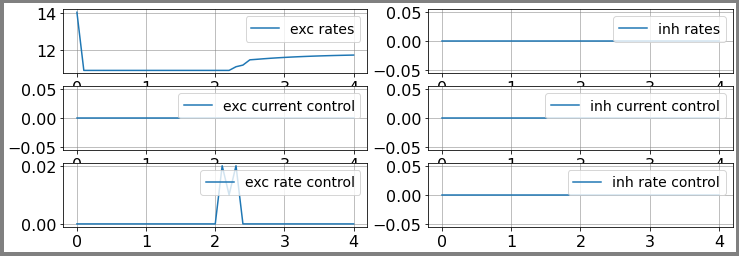

In [179]:
setinitvars(high_state_vars)

dur = 3.
dur_pre = 1.
dur_post = 1.

n_dur = int(np.around(dur/aln.params.dt + 1.,1))
n_pre = int(np.around(dur_pre/aln.params.dt + 1.,1))
n_post = int(np.around(dur_post/aln.params.dt + 1.,1))

aln.params.duration = dur + dur_pre

control_ind = [2]
prec_var = [0]

if control_ind[0] == 0 or control_ind[0] == 1:
    max_cntrl = 15.
    min_cntrl = -15.
else:
    max_cntrl = 0.1
    min_cntrl = 0.

control0 = aln.getZeroControl()
#control0[0,control_ind,:] =  np.sin(np.arange(0,dur+1, 1))
#control0[0,control_ind,0] = 1.
for j in control_ind:
    #control0[0,j,n_pre + 0] = 1.0 * max_cntrl - 0.0 * min_cntrl
    #control0[0,j,n_pre + 1] = 0.4 * max_cntrl - 0.2 * min_cntrl
    control0[0,j,n_pre + 10] = 0.2 * max_cntrl - 0.2 * min_cntrl
    control0[0,j,n_pre + 11] = 0.1 * max_cntrl #- 0.2 * min_cntrl
    control0[0,j,n_pre + 12] = 0.2 * max_cntrl #+ 0.3 * min_cntrl
    #control0[0,j,n_pre + 6] = 0.2 * max_cntrl #- 0.6 * min_cntrl
    #control0[0,j,n_pre + 7] = 0.2 * max_cntrl + 0.8 * min_cntrl

plotFunc.plot_traces(aln, control0)

aln.params.duration = dur
target = aln.getZeroTarget()
target[0,0,:] = aln.rates_exc[0,n_pre-1:]
target[0,1,:] = aln.rates_inh[0,n_pre-1:]

control1 = aln.getZeroControl()
for k in range(1, control1.shape[2]-2):
    control1[0,j,k] += random.uniform(0., 1.) * 0.1 * max_cntrl

In [180]:
costparams = [1. * 1e0, 1.* 1e2, 1.* 1e1]
#costparams = [9.9, 5., 0.]
cost.setParams(costparams[0], costparams[1], costparams[2])

setinitvars(high_state_vars)
max_it = 1000
start_step = 10.
alg = "A1"
case = "test"

aln.params.duration = dur
    
control1 = aln.getZeroControl()
control2 = bestControlA[:,:,n_pre-1:-n_pre+1]
control3 = control0[:,:,n_pre-1:]
control3[0,2,:] *= 1.
control5 = bestControlA_A2[:,:,n_pre-1:-n_post+1]

cvar = [None, "HS", "FR", "PR", "HZ"]
cgv = cvar[0]

bestControlA, bestStateA, costA, runtimeA, grad = aln.A1(control3, target,
        c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl,
        t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post,
        CGVar = cgv, control_variables_ = control_ind, prec_variables_ = prec_var)

for j in control_ind:
    print("control ind ", j )
    print("grad = ", grad[0,j,:])
    print("best control = ", bestControlA[0,j,:])

for i in range(1, len(costA)):
    if costA[i-1] < costA[i]:
        print("ERROR ---------------- in index ", i)
        
print("total runtime = ", runtimeA[-1])
# -9.11609228e-02
# 0.002345565904937199

print("max grad value = ", np.amax(np.abs( grad[0,control_ind[0],:] ) ) )

set cost params
RUN  0 , total integrated cost =  0.09936832980505142
RUN  1 , total integrated cost =  0.09311809837905045
RUN  2 , total integrated cost =  0.08742154890745824
RUN  3 , total integrated cost =  0.08362929096558354
RUN  4 , total integrated cost =  0.0801033932387759
RUN  5 , total integrated cost =  0.07748176531286805
RUN  6 , total integrated cost =  0.07499366876761121
RUN  7 , total integrated cost =  0.07212130156050937
RUN  8 , total integrated cost =  0.06940746876916823
RUN  9 , total integrated cost =  0.06749430936301774
RUN  10 , total integrated cost =  0.06577990132179792
RUN  11 , total integrated cost =  0.0635409156422825
RUN  12 , total integrated cost =  0.06141710595139298
RUN  13 , total integrated cost =  0.06022832424430694
RUN  14 , total integrated cost =  0.05918122160521992
RUN  15 , total integrated cost =  0.05823898728920547
RUN  16 , total integrated cost =  0.057393326611199925
RUN  17 , total integrated cost =  0.05657414543723367
RUN  

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  228 , total integrated cost =  0.05050132591670737
Improved over  228  iterations by  49.177644410664016  percent.
Problem in initial value trasfer:  sigmae_f 1.8576470588235297 10.889999999999999
Problem in initial value trasfer:  sigmai_f 1.0841042893187554 0.0
Problem in initial value trasfer:  sigmae_f 3.385074861554279 11.41662380742751
Problem in initial value trasfer:  sigmai_f 1.0786750205452749 0.0
control ind  2
grad =  [-9.33936998e-07 -9.26065828e-07 -9.08747420e-07 -8.84761955e-07
 -8.56826310e-07 -8.30286746e-07 -8.16701578e-07 -8.38898456e-07
 -9.38063271e-07 -1.18330763e-06 -1.67451346e-06  1.21790685e-06
 -6.59387542e-07  1.54080105e-06 -1.83879161e-06 -1.06180506e-06
 -6.80212759e-07 -4.96641928e-07 -4.08411938e-07 -3.61073300e-07
 -3.27622161e-07 -2.95982907e-07 -2.61767680e-07 -2.24237853e-07
 -1.84152621e-07 -1.42697039e-07 -1.01009029e-07 -6.00285119e-08
 -2.05455639e-08  6.36753147e-02  0.00000000e+00]
best control =  [0.0000

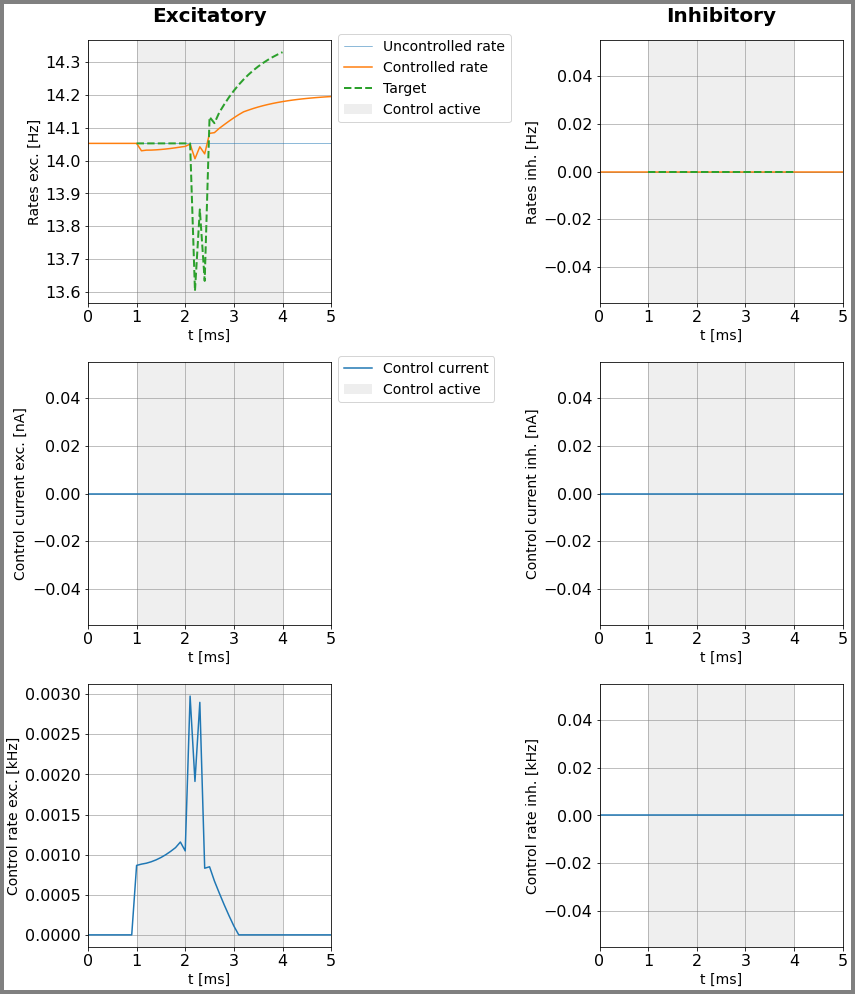

In [177]:
plotFunc.plot_control(aln, bestControlA, dur, dur_pre, dur_post, high_state_vars, target, path)

In [178]:
cost.setParams(costparams[0], costparams[1], costparams[2])
setinitvars(high_state_vars)
max_it = 10
start_step = 1.
alg = "A2"
case = "test"
incl_step = 10
test_step = 1e-6

aln.params.duration = dur
control3 = aln.getZeroControl()
control4 = bestControlA[:,:,n_pre-1:-n_pre+1]
#control4[0,2,:20] = 0.
#control6 = bestControlA_A2[:,:,n_pre-1:-n_pre+1]

bestControlA_A2, bestStateA_A2, costA_A2, runtimeA_A2 = aln.A2(control4, target,
        max_iteration_ = max_it,  tolerance_ = tol, include_timestep_ = incl_step,
        start_step_ = start_step, test_step_ = test_step, max_control_ = max_cntrl,
        min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre,
        t_sim_post_ = dur_post, control_variables_ = control_ind, prec_variables_ = prec_var)

for i in range(1, len(costA_A2)):
    if costA_A2[i-1] < costA_A2[i]:
        print("ERROR ---------------- in index ", i)
        
print(bestControlA_A2[0,control_ind[0],:])

# 0.009869078053036093

ERROR:root:not implemented for less than full timesteps


set cost params
RUN  0 , total integrated cost:  0.0450139339507247


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  1 , total integrated cost:  0.0450139339507247
Improved over  1  iterations by  0.0  percent.
Problem in initial value trasfer:  sigmae_f 1.8236039391260297 14.02960739316715
Problem in initial value trasfer:  sigmai_f 1.0664360163431024 0.0
Problem in initial value trasfer:  sigmae_f 2.5066034649775704 14.038860152295383
Problem in initial value trasfer:  sigmai_f 1.0658802757880514 0.0
[0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.00086602 0.00088202
 0.00089336 0.00091129 0.00093486 0.00096426 0.0009996  0.0010412
 0.00108747 0.00115743 0.00104665 0.0029772  0.00191321 0.00289916
 0.00083095 0.00084898 0.00067169 0.0005211  0.0003763  0.0002392
 0.0001097  0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.        ]


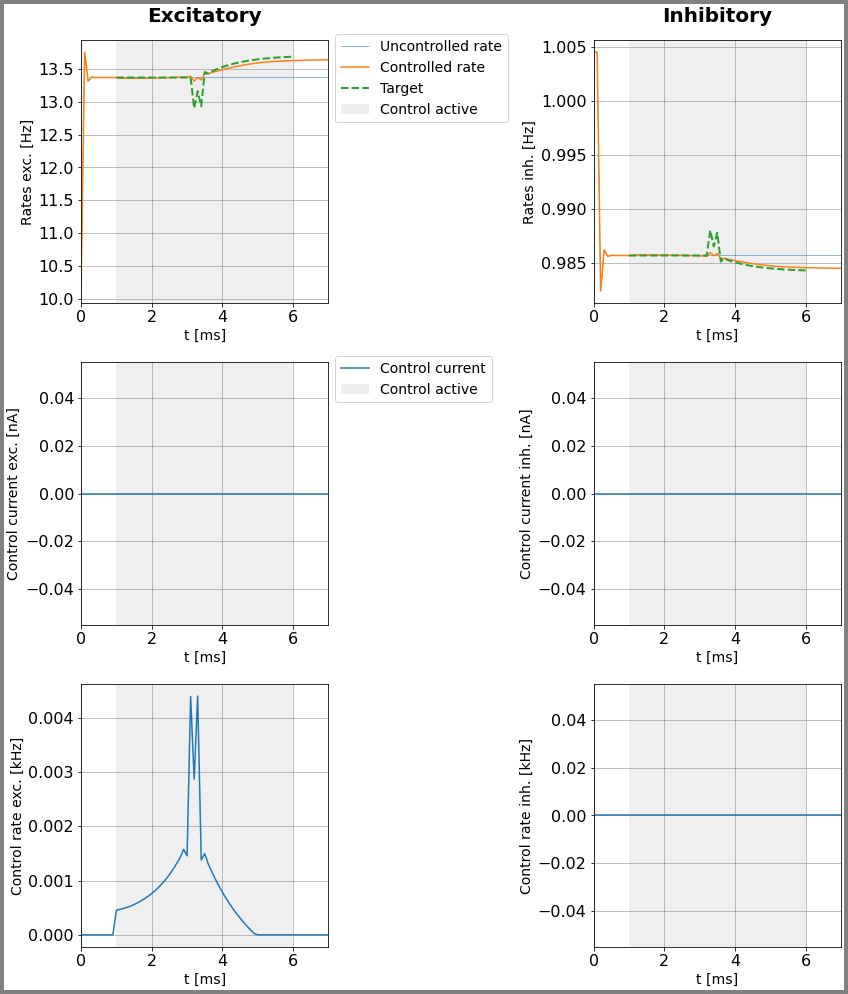

In [170]:
plotFunc.plot_control(aln, bestControlA_A2, dur, dur_pre, dur_post, high_state_vars, target, path)

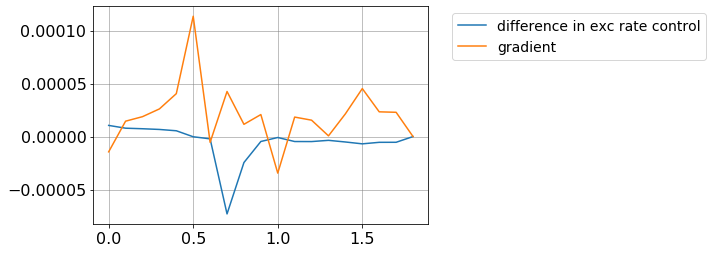

In [1219]:
diff = bestControlA_A2 - bestControlA
#diff[0,2,-2:] = 0.

#c_diff = costA_A2[6] - costA[3]
#print(c_diff)

t = np.arange(0,dur+0.1, 0.1)

#plt.plot(t, diff[0,0,:], label="difference in exc current control")
#plt.plot(t, diff[0,1,:], label="difference in inh current control")
#plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
#plt.grid()
#plt.show()

plt.plot(t, diff[0,2,n_pre-1:-n_post+1], label="difference in exc rate control")
#plt.plot(t, diff[0,3,n_pre:-n_post], label="difference in inh rate control")
plt.plot(t, grad[0,2,:], label="gradient")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()

### Testcases

1. PRECISION ONLY, NO DELAY
    - [x] 0 control, 0 precision measure, no delay
    - [x] 1 control, 1 precision measure, no delay
    - [x] 0 control, 1 precision measure, no delay
    - [x] 1 control, 0 precision measure, no delay
    - [] 2 control, 0 precision measure, no delay (slow to converge)
    - [] 2 control, 1 precision measure, no delay (slow to converge)

2. PRECISON + ENERGY + SPARSITY, NO DELAY
    - [x] 0 control, 0 precision measure, no delay
    - [x] 1 control, 1 precision measure, no delay
    - [] 0 control, 1 precision measure, no delay (requires different weights, gradient vanishes, A2 performes differently and worse)
    - [] 1 control, 0 precision measure, no delay (requires different weights, gradient vanishes, A2 performes differently and worse)
    - [x] 2 control, 0 precision measure, no delay
    - [] 2 control, 1 precision measure, no delay (requires different weights, zero control as output, gradient nonvanishing because on boundary. At higher weights, gradient vanishes)
    
3. PRECISION ONLY, DELAY
    - [x] 0 control, 0 precision measure, delay
    - [x] 1 control, 1 precision measure, delay
    - [] 0 control, 1 precision measure, delay (not in every case, could have several solutions)
    - [] 1 control, 0 precision measure, delay (not in every case, could have several solutions)
    - [x] 2 control, 0 precision measure, delay (sometimes slow convergence)
    - [x] 2 control, 1 precision measure, delay (sometimes slow to converge)

4. PRECISON + ENERGY + SPARSITY
    - [] 0 control, 0 precision measure, delay (gradient does not quite vanish)
    - [] 1 control, 1 precision measure, delay (gradient does not quite vanish)
    - [] 0 control, 1 precision measure, delay (requires different weights, gradient does not quite vanish, A2 performes differently and worse)
    - [] 1 control, 0 precision measure, delay (requires different weights, gradient does not quite vanish, A2 performes differently and worse)
    - [] 2 control, 0 precision measure, delay (gradient does not quite vanish)
    - [] 2 control, 1 precision measure, delay (requires different weights, gradient does not quite vanish, A2 performes differently and worse)
    
The cost functional should always have more than one minimum. If the "direct" control (0,0; 1,1; 2,0; 3,1) is not applied, it is much more likely to end up in a local minimum, because there is no "dominant" contribution.

### What to take into account and don't forget
- if delay is present, always leave sufficient time steps before and after applying control
- allowing rates smaller than zero may cause trouble, because then same input can have different effect at different points of time
- is the fact that control enters computation at various points causing problems?
- if stuff of different orders of magnitude is competing, convergence is slow
- convergence in integration variables is much slower than in direct input
- make sure variables are in proper range: setting e.g. sigma to zero in time integration can cause problems
- the dynamics should not be explicitly dependent on time, otherwise adjoint formulation does not hold in this way
- apparently, also time-independent contributions mess up wiht the algorithm